In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
%run getRegularH.ipynb import getRegularH
%run remove_4cycle.ipynb import remove_4cycle

In [5]:
def Peeling_Decoder(Hcl, erasures):
    """
    returns reisudla number of erasures after peeling decoding, erasures is a
    binary (logical) vector indicating at which vns erasures are present
    note that the performance of the peeling decoder is equivalent to the one
    of the BEC message passing decoder, as has been proven in M. Stinner, L.
    Barletta, P. Olmos, "Finite-length scaling based on belief propagation
    for spatially coupled LDPC codes", https://arxiv.org/pdf/1604.05111.pdf
    """
    H = Hcl[:,erasures].copy()
    # find degree-1 checks
    dc1checks = np.sum(H, axis=1) == 1
    assoc_vns = np.asarray(H[dc1checks,:]).nonzero()[1]
    E = H.shape[1]

    while assoc_vns.size > 0:
        H = np.delete(H, assoc_vns, axis=1)
        dc1checks = np.sum(H, axis=1) == 1
        assoc_vns = np.asarray(H[dc1checks,:]).nonzero()[1]
        E = H.shape[1]
    
    return E

def simulate():
    remove_4cycles = True

    dv = 3
    dc = 6
    n = 200

    eps_range = np.linspace(0.1, 0.43, 15)

    epochs = np.full(len(eps_range), 200, dtype=int)

    frames = 3000

    errors = []

    epsi = 0

    for epsilon in tqdm(eps_range):
        print(epsilon)
        num_err = 0

        for _ in range(int(epochs[epsi])):

            H = getRegularH(n, dv, dc)
            if remove_4cycles:
                H, _ = remove_4cycle(H)
            
            for _ in range(frames):
                erasures = np.where(np.random.rand(n) < epsilon)[0]
                E = Peeling_Decoder(H, erasures)

                if E > 0:
                    num_err += 1
        
        errors.append(num_err / epochs[epsi] / frames)
        epsi += 1
    
    plt.figure()
    plt.semilogy(eps_range, errors, marker='o')
    plt.xlabel("epsilon")
    plt.ylabel("Block error rate")
    plt.grid(True, which="both")
    plt.show()

  0%|          | 0/15 [00:00<?, ?it/s]

0.1
0.12357142857142858
0.14714285714285713
0.1707142857142857
0.19428571428571428
0.21785714285714286
0.2414285714285714
0.265
0.2885714285714286
0.31214285714285717
0.33571428571428574
0.3592857142857143
0.3828571428571428
0.40642857142857136
0.43


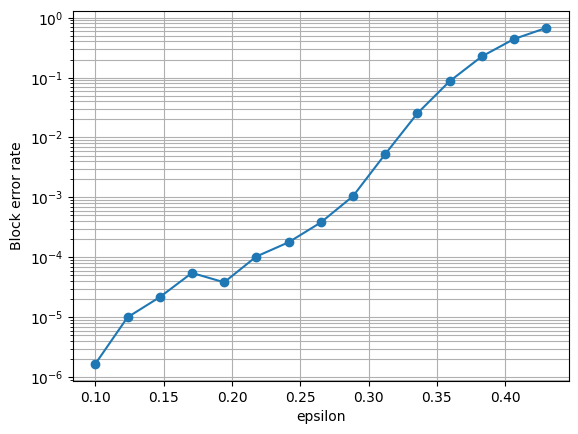

In [6]:
simulate()